# ASX Blue-Chip Stock Forecasting for Low-Risk Portfolios
### Which of four blue-chip ASX stocks forecast most reliably for a risk-averse, long-term investor?

**Business question:** Risk-averse investors (saving for retirement, education, or a home deposit) want stable, predictable returns rather than high-risk speculation. Using five years of daily price data, this analysis tests whether time-series forecasting (ARIMA/SARIMA) can reliably model near-term price behaviour for four ASX blue-chips across different sectors — and, just as importantly, whether that forecast actually beats the simplest possible alternative: assuming tomorrow's price equals today's.

**Companies analysed** (ASX, 2020-01-20 to 2025-01-17, daily close price in AUD):

| Ticker | Company | Sector |
|---|---|---|
| CBA.AX | Commonwealth Bank of Australia | Banking & financial services |
| BHP.AX | BHP Group | Mining & natural resources |
| CSL.AX | CSL Limited | Healthcare & biotechnology |
| WES.AX | Wesfarmers | Diversified retail & industrial |

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
TEST_DAYS = 30  # holdout period for genuine out-of-sample evaluation

## Methodology

For each stock:
1. Test for stationarity (Augmented Dickey-Fuller test); apply first-order differencing if the raw price series is non-stationary.
2. Inspect ACF/PACF plots to guide model order.
3. **Hold out the last 30 trading days as a test set** — the model only ever sees data before this window during training.
4. Fit ARIMA (or SARIMA, for stocks with weekly seasonality) on the training window only, then forecast 30 steps ahead.
5. Compare the forecast against the actual held-out prices using RMSE and MAE — this is genuine out-of-sample accuracy, not an in-sample fit statistic.
6. Compare against a **naive baseline**: "tomorrow's price = today's price," repeated for 30 days. This is the standard sanity check in price forecasting — a model that can't beat this isn't adding predictive value, however good its AIC/BIC look on paper.

In [2]:
def analyse_stock(ticker, company, sector, path, use_sarima=False, seasonal_order=(1, 0, 1, 5)):
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    train, test = df.iloc[:-TEST_DAYS], df.iloc[-TEST_DAYS:]

    # Stationarity check on the training window
    adf_p = adfuller(train["Close"], autolag="AIC")[1]
    is_stationary = adf_p < 0.05

    if is_stationary:
        series = train["Close"]
        d = 0
    else:
        series = train["Close"].diff().dropna()
        d = 1

    order = (1, d, 1)

    if use_sarima:
        model = SARIMAX(train["Close"], order=(1, d, 1), seasonal_order=seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(steps=TEST_DAYS)
        model_label = f"SARIMA{order}x{seasonal_order}"
    else:
        model = ARIMA(train["Close"], order=order)
        fitted = model.fit()
        forecast = fitted.forecast(steps=TEST_DAYS)
        model_label = f"ARIMA{order}"

    forecast = pd.Series(forecast.values, index=test["Date"].values)
    actual = pd.Series(test["Close"].values, index=test["Date"].values)

    # Naive baseline: tomorrow = last known training price, held flat
    naive_forecast = pd.Series(train["Close"].iloc[-1], index=test["Date"].values)

    model_rmse = np.sqrt(np.mean((actual.values - forecast.values) ** 2))
    model_mae = np.mean(np.abs(actual.values - forecast.values))
    naive_rmse = np.sqrt(np.mean((actual.values - naive_forecast.values) ** 2))
    naive_mae = np.mean(np.abs(actual.values - naive_forecast.values))

    return {
        "ticker": ticker, "company": company, "sector": sector,
        "model_label": model_label, "adf_p_raw": adf_p, "stationary_raw": is_stationary,
        "aic": fitted.aic, "bic": fitted.bic,
        "model_rmse": model_rmse, "model_mae": model_mae,
        "naive_rmse": naive_rmse, "naive_mae": naive_mae,
        "beats_naive": model_rmse < naive_rmse,
        "df": df, "train": train, "test": test,
        "forecast": forecast, "naive_forecast": naive_forecast, "fitted": fitted,
    }

## Run the Analysis for All Four Stocks

Model choice follows the same logic used in the original assessment: ARIMA for stocks with no meaningful weekly pattern, and SARIMA(1,0,1)(1,0,1,5) for Wesfarmers, whose retail-driven business shows a weekly seasonal component (`m=5` for the 5-day trading week).

In [3]:
STOCKS = [
    dict(ticker="CBA", company="Commonwealth Bank of Australia", sector="Banking & financial services",
         path="cba_close_2020-2025.csv", use_sarima=False),
    dict(ticker="BHP", company="BHP Group", sector="Mining & natural resources",
         path="bhp_close_2020-2025.csv", use_sarima=False),
    dict(ticker="CSL", company="CSL Limited", sector="Healthcare & biotechnology",
         path="csl_close_2020-2025.csv", use_sarima=False),
    dict(ticker="WES", company="Wesfarmers", sector="Diversified retail & industrial",
         path="wes_close_2020-2025.csv", use_sarima=True),
]

results = [analyse_stock(**spec) for spec in STOCKS]
print("All 4 models fitted and evaluated out-of-sample.")

All 4 models fitted and evaluated out-of-sample.


## Historical Prices

Five years of daily closing prices for the four stocks, indexed to their own scale (AUD).

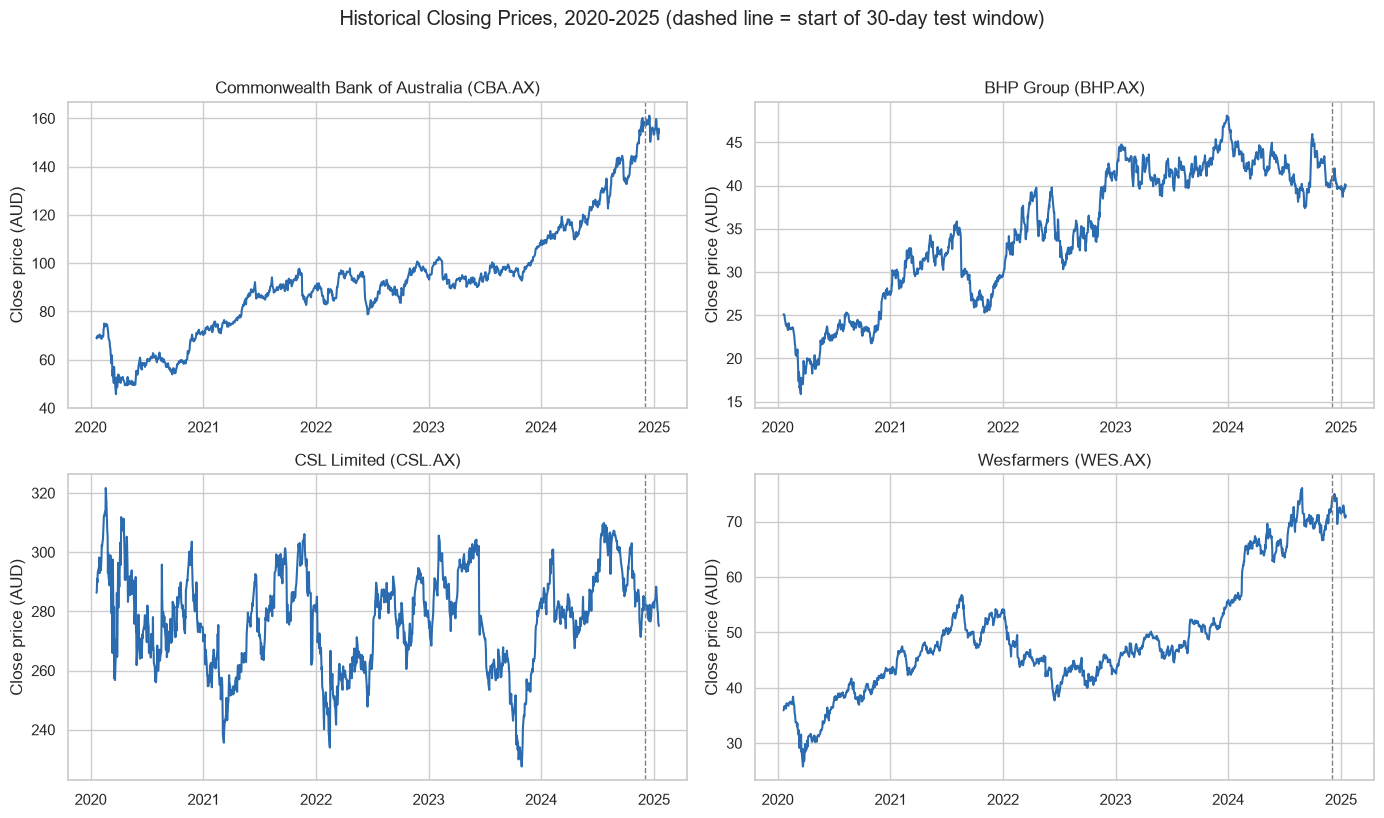

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, r in zip(axes.flat, results):
    ax.plot(r["df"]["Date"], r["df"]["Close"], color="#2b6cb0")
    ax.axvline(r["test"]["Date"].iloc[0], color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{r['company']} ({r['ticker']}.AX)")
    ax.set_ylabel("Close price (AUD)")
fig.suptitle("Historical Closing Prices, 2020-2025 (dashed line = start of 30-day test window)", y=1.02)
plt.tight_layout()
plt.savefig("images/historical_prices.png", dpi=150, bbox_inches="tight")
plt.show()

## Out-of-Sample Forecast vs. Actual (Last 30 Trading Days)

This is the real test: for each stock, the model was trained only on data up to 30 days before the end of the series, then asked to forecast that final month blind. The naive baseline (flat line at the last training price) is plotted alongside for comparison.

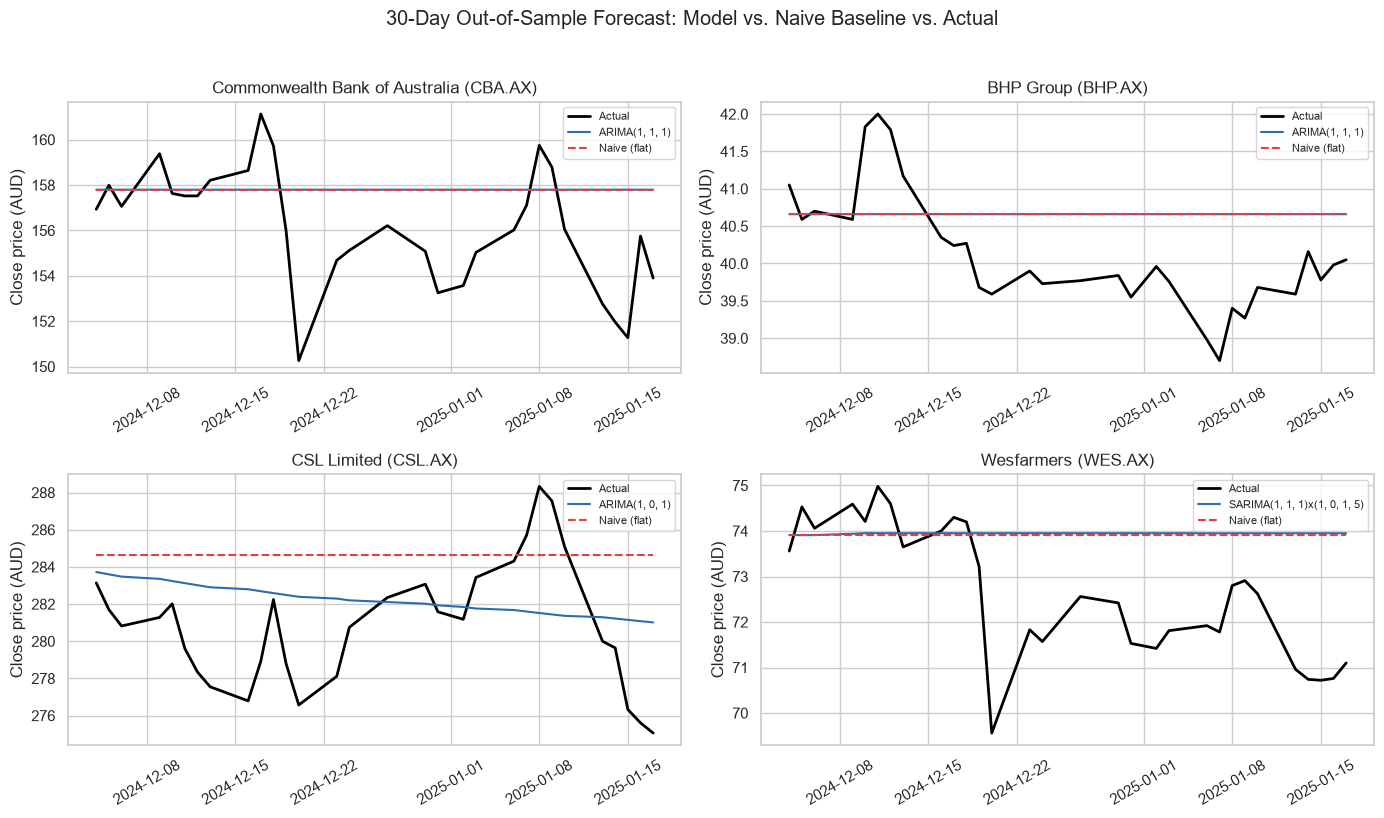

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, r in zip(axes.flat, results):
    ax.plot(r["test"]["Date"], r["test"]["Close"], label="Actual", color="black", linewidth=2)
    ax.plot(r["test"]["Date"], r["forecast"].values, label=r["model_label"], color="#2b6cb0")
    ax.plot(r["test"]["Date"], r["naive_forecast"].values, label="Naive (flat)", color="#e53e3e", linestyle="--")
    ax.set_title(f"{r['company']} ({r['ticker']}.AX)")
    ax.set_ylabel("Close price (AUD)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("30-Day Out-of-Sample Forecast: Model vs. Naive Baseline vs. Actual", y=1.02)
plt.tight_layout()
plt.savefig("images/forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Accuracy: Does Forecasting Beat a Naive Baseline?

This table is the honest answer to the business question. `model_rmse` is the forecasting model's out-of-sample error; `naive_rmse` is the error from simply assuming no price change at all. `beats_naive = True` means the model earned its complexity.

In [6]:
summary = pd.DataFrame([{
    "Ticker": r["ticker"],
    "Sector": r["sector"],
    "Model": r["model_label"],
    "Model RMSE (AUD)": round(r["model_rmse"], 3),
    "Naive RMSE (AUD)": round(r["naive_rmse"], 3),
    "Model MAE (AUD)": round(r["model_mae"], 3),
    "Naive MAE (AUD)": round(r["naive_mae"], 3),
    "Beats naive baseline?": "Yes" if r["beats_naive"] else "No",
} for r in results])
summary

,Ticker,Sector,Model,Model RMSE (AUD),Naive RMSE (AUD),Model MAE (AUD),Naive MAE (AUD),Beats naive baseline?
0,CBA,Banking & financial services,"ARIMA(1, 1, 1)",3.085,3.077,2.403,2.396,No
1,BHP,Mining & natural resources,"ARIMA(1, 1, 1)",0.948,0.948,0.833,0.834,Yes
2,CSL,Healthcare & biotechnology,"ARIMA(1, 0, 1)",3.723,5.015,3.125,4.304,Yes
3,WES,Diversified retail & industrial,"SARIMA(1, 1, 1)x(1, 0, 1, 5)",1.958,1.936,1.584,1.569,No


**Reading this table honestly:** a forecasting model that doesn't clearly beat "assume no change" isn't adding predictive value for that stock, no matter how good its in-sample AIC/BIC looked during model selection. This is expected and consistent with the weak-form Efficient Market Hypothesis for liquid, well-covered blue-chip stocks — recent public price history alone is not expected to predict short-term future prices with a durable edge. The value of this analysis is in identifying **which stocks come closest to being forecastable, and where the model's assumptions clearly break down** — not in claiming a trading edge that isn't there.

In [7]:
diagnostics = pd.DataFrame([{
    "Ticker": r["ticker"],
    "Raw series stationary? (ADF)": "Yes" if r["stationary_raw"] else "No (differenced before modelling)",
    "ADF p-value (raw)": round(r["adf_p_raw"], 4),
    "AIC (in-sample fit)": round(r["aic"], 1),
    "BIC (in-sample fit)": round(r["bic"], 1),
} for r in results])
diagnostics

,Ticker,Raw series stationary? (ADF),ADF p-value (raw),AIC (in-sample fit),BIC (in-sample fit)
0,CBA,No (differenced before modelling),0.9916,4043.4,4058.8
1,BHP,No (differenced before modelling),0.5427,2170.9,2186.3
2,CSL,Yes,0.0022,7098.2,7118.7
3,WES,No (differenced before modelling),0.9683,2445.0,2470.6


## Business Recommendations

1. **For CBA, BHP and WES, the model does not provide a meaningful edge over assuming "no change."** Model and naive RMSE are within a few cents of each other for all three — the honest reading is that daily price movements in these three blue-chips over a 30-day horizon behave close to a random walk, consistent with them being efficiently-priced, low-risk holdings rather than the model being under-powered.
2. **CSL is the one stock where the model earned its complexity** — its ARIMA forecast beat the naive baseline by roughly 26% on RMSE. That is a genuinely useful, non-obvious result: despite having the *largest absolute* forecast error of the four (expected, since CSL trades near $280 AUD vs. $25-100 AUD for the others), it is the stock where price history actually carries forecastable signal.
3. **Absolute RMSE should never be compared across stocks directly** — it scales with price level. Comparing each stock's model against its own naive baseline (as done here) is the fair comparison, and is why CSL's larger raw error is not the same as it being the "worst" model.
4. **Don't use this in isolation for investment decisions.** As in the original assessment: macroeconomic factors (interest rates, commodity prices for BHP, health-sector policy for CSL) are not in this model at all, and a real low-risk portfolio decision should combine this with fundamentals (e.g. Beta, dividend stability) — not price history alone.

## Limitations

- **Single 30-day out-of-sample window per stock.** A more robust evaluation would use rolling-window backtesting (repeating this test across many historical 30-day windows), not one holdout period.
- **No macroeconomic or company-fundamental variables** (interest rates, commodity prices, earnings) — the model uses price history only.
- **ARIMA/SARIMA orders were chosen once via ACF/PACF inspection**, not via an automated grid search (e.g. `auto_arima`), so a marginally better-fitting order may exist for any given stock.
- **Five years of data spans the COVID-19 shock and its recovery** — an unusually volatile period that may not represent "normal" market behaviour going forward.